In [1]:
# Experiment (Visualization) note on n-gram language modeling (notebook scale but with visualization)
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 16],  # 16 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)


# 1. load a small subset of the dataset (checked)
# 2. tokenize & build data loader (checked)
# 3. train with SoRL. 
# 4. visualize abstraciton dynamics (similar to copy-n-paste, but more generally on per-n-gram statistics)

In [2]:
from data.tinystory_local import TinyStoriesDataLoader, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 36
K = 4
loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device='cpu')

doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
batch_size = 8
memory_span = 2 * max_len + 2
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories train...
Loaded 100 stories, 3600 tokens total, 0.01 MB
Collected 726 unique 4-chunks


In [3]:
# train SoRL 

# Dynamic Visualization of SoRL
# 1. select-one SoRL
from sorl.neo_utils import sorl_rollout_v2, select_best_per_doc, select_best_per_doc_v2, sorl_evaluate_v2, compute_vocab_utilization_rate
from sorl.topo import orthogonalize_abs_param
from collections import defaultdict
from sorl.info import SoRLLoss, SoRLLoss_v2, SoRLLoss_v3, SoRLLoss_v4, SoRLLoss_v5

# --- orthogonal initialization on abs param --- 
orthogonalize_abs_param(model, do_wte=True, do_head=True)

loss_fn = SoRLLoss_v5(model.vocab_sizes[1], decay=0.8, target_vocab_util=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 400 
alpha_abs = 0.1
alpha_soft_zipf = 1.0
alpha_topo = 0.0
r_min = 1.0 
reward_mode = 1

record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    tokens, doc_ids = loader.get_batch(batch_size)

    with torch.no_grad(): 
        # --- breakdown of SoRL search (select one per-document) ---
        search_data, search_ppt = sorl_rollout_v2(tokens, model, n=n, K=K, 
                                    max_iterations=max_iterations,
                                    memory_span=memory_span,
                                    attn_blocksize=attn_blocksize,
                                    temperature=temperature,
                                    truncate_seq_len=False)
        search_ppt = search_ppt.reshape(search_data.shape[0], -1)

        levels = (search_data >= model.vocab_sizes[0]).long()
        best_data, best_ppt, best_ppt_advantage, utility_reward = select_best_per_doc_v2(search_data, search_ppt, levels, r_min=r_min, reward_mode=reward_mode)

    # --- compute loss --- 
    traj_loss, abs_loss, zipf_bigram_loss, topo_loss = loss_fn(best_data, model, memory_span, attn_blocksize, utility_reward[1:])
    loss = traj_loss + alpha_abs * abs_loss + alpha_soft_zipf * zipf_bigram_loss + alpha_topo * topo_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, abs_logits, abs_tokens = sorl_evaluate_v2(tokens, model, n=2, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, zipf_bigram_loss, topo_loss = loss_fn(val_tokens, model, memory_span, attn_blocksize, torch.ones_like(val_tokens[..., 1:]))
            abs_stats.update(abs_logits, traj_loss, abs_tokens, doc_ids)
            record['vocab_util'].append(abs_stats.vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            record['topo_loss'].append(topo_loss.item())
            record['bigram_rep_rate'].append(abs_stats.bigram_rep_rate)
            record['kl_soft_zipf'].append(zipf_bigram_loss.item())

        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {abs_stats.vocab_util * 100:.2f}%  | bigram-zipf kl: {zipf_bigram_loss.item():.2f} | topo similarity: {-topo_loss.item():.2f} | bigram rep rate: {abs_stats.bigram_rep_rate:.2f}")
        
        img = visualize_dynamics(abs_stats, loader, model, enc, K, step)
        img_frames.append(img)
        break


validation step 0 | traj_loss: 10.74 | abs_loss: 8.81 | search adv: 0.08% | vocab util: 81.25%  | bigram-zipf kl: 61.83 | topo similarity: 0.95 | bigram rep rate: 0.93


In [4]:
# Save & load the model
# torch.save(model.state_dict(), 'sorl_tinystories.pt')

# --- Load model, prepare abs stats record ---
model.load_state_dict(torch.load('sorl_tinystories.pt'))

abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

abs_stats_post = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# Ordered Training
# Question #1. What order should I use? 
# -> Dumb Answer #1. Don't know, just 1 -> 100. 

# Question #2. How do I initialize the forgetting matrix? 
# -> Dumb Answer #1. I would dumbly loop through all data to get their abs_seqs (rep) & utility (memory level)

# Question #3. If abstract seqs for a data change, doesn't forgetting matrix change? 
# -> Dumb Answer #1. Yes, so we track forget matrix for every step

In [7]:
# ---- Full dataset statistics (before train) ---
from sorl.forget import train_forget_vec
from tqdm import tqdm as tqdm

forget_mat = torch.zeros(num_stories, num_stories, device=model.device)
train_idx = 0
for train_idx in tqdm(range(num_stories)): 
    forget_vec = train_forget_vec(train_idx, loader, model, abs_stats, abs_stats_post, optimizer, 
                                max_iterations, memory_span, attn_blocksize, temperature, K, r_min, reward_mode, loss_fn, alpha_abs, alpha_soft_zipf, alpha_topo,
                                ckpt_path="sorl_tinystories.pt")
    forget_mat[train_idx] = forget_vec 

  0%|          | 0/100 [00:00<?, ?it/s]

Step 0 | traj_loss: 1.14 | abs_loss: 0.42 | search adv: 39.88% | bigram-zipf kl: 18.76 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 1 | traj_loss: 0.87 | abs_loss: 0.66 | search adv: 48.79% | bigram-zipf kl: 14.90 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 2 | traj_loss: 0.76 | abs_loss: 0.51 | search adv: 42.49% | bigram-zipf kl: 11.88 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 3 | traj_loss: 0.70 | abs_loss: 0.38 | search adv: 49.74% | bigram-zipf kl: 9.54 | topo similarity: 0.00 | bigram rep rate: 1.00


  1%|          | 1/100 [00:10<17:04, 10.34s/it]

Step 0 | traj_loss: 1.10 | abs_loss: 0.38 | search adv: 43.39% | bigram-zipf kl: 7.34 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 1 | traj_loss: 0.92 | abs_loss: 0.70 | search adv: 37.33% | bigram-zipf kl: 5.81 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 2 | traj_loss: 0.67 | abs_loss: 0.87 | search adv: 54.79% | bigram-zipf kl: 4.64 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 3 | traj_loss: 0.56 | abs_loss: 0.87 | search adv: 58.06% | bigram-zipf kl: 3.75 | topo similarity: 0.00 | bigram rep rate: 1.00


  2%|▏         | 2/100 [00:20<16:53, 10.34s/it]

...

 98%|█████████▊| 98/100 [17:03<00:20, 10.46s/it]

Step 0 | traj_loss: 0.80 | abs_loss: 0.37 | search adv: 50.93% | bigram-zipf kl: 0.43 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 1 | traj_loss: 0.67 | abs_loss: 0.43 | search adv: 56.82% | bigram-zipf kl: 0.42 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 2 | traj_loss: 0.55 | abs_loss: 0.38 | search adv: 61.08% | bigram-zipf kl: 0.45 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 3 | traj_loss: 0.43 | abs_loss: 0.40 | search adv: 61.73% | bigram-zipf kl: 0.46 | topo similarity: 0.00 | bigram rep rate: 1.00


 99%|█████████▉| 99/100 [17:13<00:10, 10.48s/it]

Step 0 | traj_loss: 1.26 | abs_loss: 0.38 | search adv: 36.93% | bigram-zipf kl: 0.53 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 1 | traj_loss: 1.25 | abs_loss: 1.06 | search adv: 33.21% | bigram-zipf kl: 0.38 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 2 | traj_loss: 1.26 | abs_loss: 0.92 | search adv: 24.76% | bigram-zipf kl: 0.37 | topo similarity: 0.00 | bigram rep rate: 1.00
Step 3 | traj_loss: 1.07 | abs_loss: 0.72 | search adv: 32.16% | bigram-zipf kl: 0.31 | topo similarity: 0.00 | bigram rep rate: 1.00


100%|██████████| 100/100 [17:24<00:00, 10.44s/it]


In [9]:
# If you want to save the tensor for later, use torch.save:
torch.save(forget_mat, "forget_mat.pt")

# To load it in the future, use:
# forget_mat = torch.load("forget_mat.pt")

In [ ]:
# Exp #1. 
# 'memory address' for abstraction representatino --> SoRL learns abstract representation that locates 'memory address'
# Exp #2. 
# 'self-organization' of abstraction representation --> will SoRL tries to pull mixing memory apart? 
# Exp #3. 
# setting up tiny memory dataset training pipeline 
# Exp #4. 
# include utility scaling in SoRL experiment

In [7]:
# Obs #1. Besides the overtrained sample, all other sample experience 'forgetting'
#         but, there is clear deviation in their specific forgetting level. The million
#         dollar question, is what correlates with the forgetting level? 
forget_vec = abs_stats_post.traj_perplexity - abs_stats.traj_perplexity

# Is abstract sim related to forgetting? 
ham_dist_vec = abs_stats.compute_cross_doc_hamming()[0]
logit_sim_vec = abs_stats.compute_cross_doc_logit_sim()[0]

forget_vec, ham_dist_vec

(tensor([-0.5339,  0.2673,  0.2412,  0.0555,  0.0888,  0.1321,  0.2042,  0.0631,
          0.1998,  0.2351,  0.0812,  0.2980,  0.5470,  0.0099,  0.1194,  0.1070,
          0.1180,  0.1144,  0.4090,  0.0961,  0.0103,  0.2657,  0.0701,  0.0957,
          0.0015,  0.4246,  0.1056, -0.0060,  0.2222, -0.0208,  0.0801,  0.1806,
          0.1556,  0.1040,  0.0657,  0.1880,  0.2149,  0.1181,  0.3771,  0.2805,
          0.0444,  0.1870,  0.0882,  0.0060,  0.0526,  0.1370,  0.0909,  0.0470,
          0.1690,  0.0668,  0.1764,  0.1839,  0.1274,  0.1531,  0.4641,  0.1549,
          0.4068,  0.0674,  0.2408,  0.0838,  0.1622,  0.1001,  0.1032,  0.1405,
          0.1501,  0.0995,  0.1385,  0.1940,  0.0888,  0.1678,  0.0705,  0.1666,
          0.3222,  0.3085,  0.1724,  0.1166,  0.2316,  0.2104,  0.2216,  0.2880,
          0.0759,  0.0948, -0.0078,  0.1614,  0.1092,  0.2694,  0.2588,  0.0280,
          0.2630,  0.1497,  0.1232,  0.1637,  0.1148,  0.0607,  0.0605,  0.0660,
          0.3132,  0.2049,  

Forgetting vs Hamming DISTANCE: r=-0.399 (p=0.0000)
Forgetting vs Logit SIMILARITY: r=0.277 (p=0.0054)


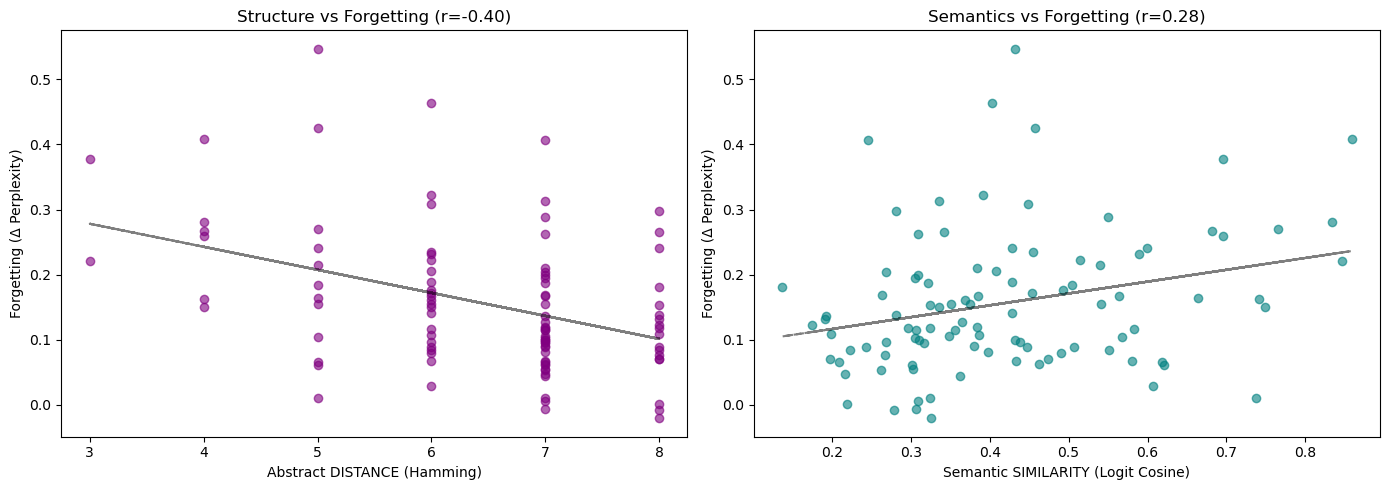

>> Evidence: Distant abstract structures are PROTECTED (Less Forgetting).
>> Samples with SHARED structure (Low Distance) interfere more.


In [8]:
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# Exclude the trained sample (idx 0) to analyze pure interference
# We assume index 0 is the trained one

mask = torch.arange(len(forget_vec)) != train_idx
y_forget = forget_vec[mask].cpu().numpy()
x_hamming_dist = ham_dist_vec[mask].cpu().numpy()  # DISTANCE now
x_logit_sim = logit_sim_vec[mask].cpu().numpy()

# 1. Pearson Correlation
corr_hamming, p_hamming = scipy.stats.pearsonr(x_hamming_dist, y_forget)
corr_logit, p_logit = scipy.stats.pearsonr(x_logit_sim, y_forget)

print(f"Forgetting vs Hamming DISTANCE: r={corr_hamming:.3f} (p={p_hamming:.4f})")
print(f"Forgetting vs Logit SIMILARITY: r={corr_logit:.3f} (p={p_logit:.4f})")

# 2. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Structure (Hamming Distance)
axes[0].scatter(x_hamming_dist, y_forget, alpha=0.6, color='purple')
axes[0].set_xlabel('Abstract DISTANCE (Hamming)')  # Corrected label
axes[0].set_ylabel('Forgetting (Δ Perplexity)')
axes[0].set_title(f'Structure vs Forgetting (r={corr_hamming:.2f})')
z = np.polyfit(x_hamming_dist, y_forget, 1)
axes[0].plot(x_hamming_dist, np.poly1d(z)(x_hamming_dist), 'k--', alpha=0.5)

# Plot 2: Semantics (Logit Sim)
axes[1].scatter(x_logit_sim, y_forget, alpha=0.6, color='teal')
axes[1].set_xlabel('Semantic SIMILARITY (Logit Cosine)')
axes[1].set_ylabel('Forgetting (Δ Perplexity)')
axes[1].set_title(f'Semantics vs Forgetting (r={corr_logit:.2f})')
z = np.polyfit(x_logit_sim, y_forget, 1)
axes[1].plot(x_logit_sim, np.poly1d(z)(x_logit_sim), 'k--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. New Interpretation
if corr_hamming < -0.3:
    print(">> Evidence: Distant abstract structures are PROTECTED (Less Forgetting).")
    print(">> Samples with SHARED structure (Low Distance) interfere more.")
elif corr_hamming > 0.3:
    print(">> Evidence: Distant abstract structures INTERFERE more (Unexpected).")

In [12]:
# Strange behavior: 
# 1. When training on 1 extra data point, its abstract sequence changes. 
# 2. When training on 1 extra data point, its perplexity increases. 
# Issue #1. -> Resolved #1. we compute batch avg perplexity, that's different from per-data-point perplexity. 

abs_before = abs_stats.abs_seqs[0]
abs_after = abs_stats_post.abs_seqs[0]

print(f"Abs seq BEFORE: {abs_before.tolist()}")
print(f"Abs seq AFTER:  {abs_after.tolist()}")
print(f"Changed: {(abs_before != abs_after).any().item()}")

Abs seq BEFORE: [50261, 50267, 50258, 50270, 50258, 50269, 50260, 50258]
Abs seq AFTER:  [50258, 50259, 50258, 50260, 50258, 50261, 50260, 50258]
Changed: True


In [ ]:
# Idea #1. Design script to compute 'forget matrix' for all data points. 


In [ ]:
# Question #4. What does the forget matrix look like? 
# -> train on sample i, we record the perplexity change of all other samples right? 
# -> so it's less about ordered training, but about train on one extra data points? 
# -> in terms of scale, pretrain >> finetune ratio exceeds well beyond 100x, so our setup is quite normal
#    from the perspective of data ratio when forgetting occurs. 
# -> Therefore, what we'd need is actually 100 forgetting matrix (when train on 1 extra data point)? 


In [14]:
# A more ideal visualization: 
# On a 3D plot, we visualize on z-axis, the perplexity level of all data points, the x-y plane is 
# similar to the clustering map of all sequences' abstraction representation. 
# When a data point(s) is trained on, we mark them in red, and visualize the dynamics of perplexity change
# This would give an extremely clear intuition on how forgetting occurs. 
from data.tinystory_local import visualize_perplexity_terrain

# doc_ids = abs_stats.valid_docs
# cs_sim = abs_stats.compute_cross_doc_logit_sim()
# img_sim = visualize_clustering(cs_sim, abs_stats, doc_ids=doc_ids, step=step, title="Story Cluster")


# img_sim

# from data.tinystory_local import visualize_perplexity_terrain
from sklearn.decomposition import PCA

cs_sim = abs_stats.compute_cross_doc_logit_sim()
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(cs_sim.cpu().numpy())
perplexity = abs_stats.traj_perplexity

# Now use in 3D visualization
img = visualize_perplexity_terrain(coords_2d, perplexity, trained_idx=0, step=step)

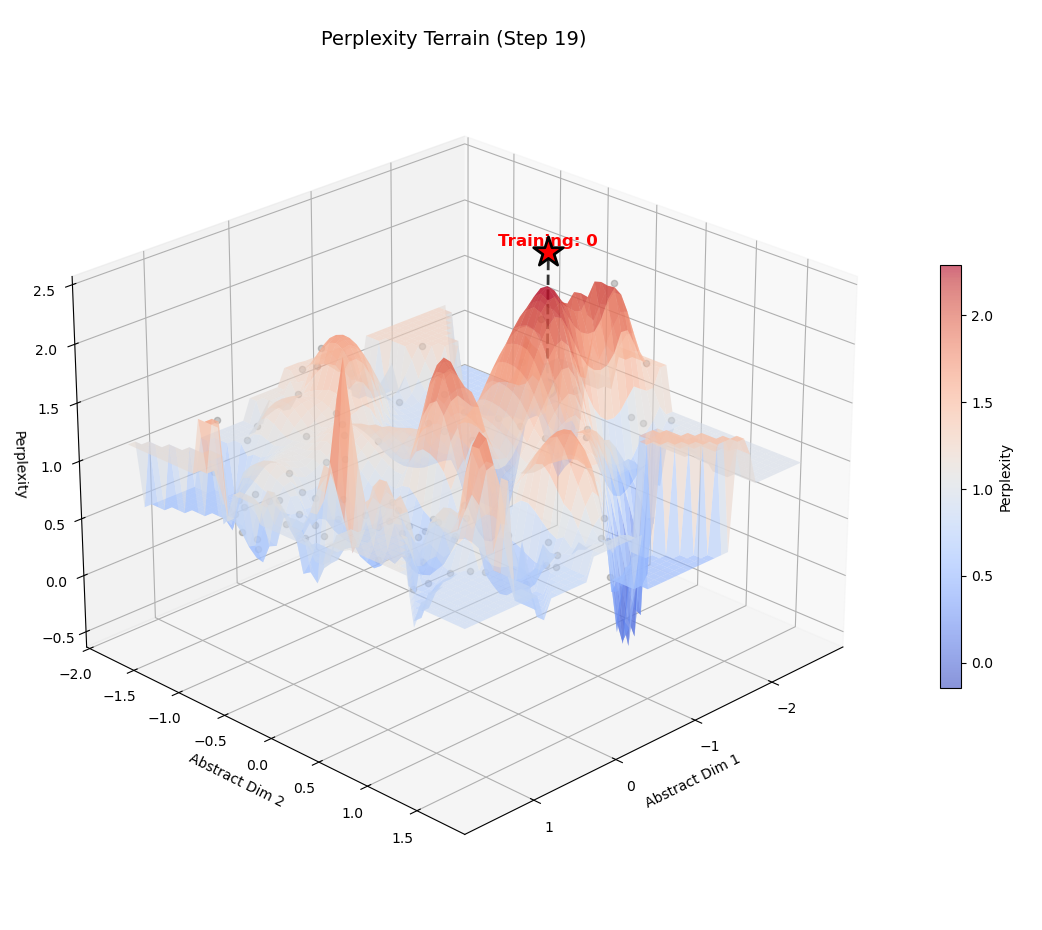

In [15]:
img

In [ ]:
# --- Forget Matrix ---

In [4]:
# Hypothesis #2. 
# ------------------------------------------------------------
# forget(i | j) is proportional to 1 / d(a_i, a_j)
# dis-similar concept is less likely to be overwritten by each other
# similar concept is more likely to be overwritten by each other
# the emerged abstraction system from SoRL can describe such similarity via d(a_i, a_j)
# ------------------------------------------------------------

# Experiment 
# (a). Train till emergence
# (b). Train with specific order. 
# (c). Record 'forgetting matrix'

import numpy as np
np.array(record['topo_loss'][:5]).mean(), np.array(record['topo_loss'][-5:]).mean()

(-0.7774280548095703, -0.7865824460983276)

In [4]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (select-best per abs SoRL + 1.0 topo reg + 1.0 bigram zipf reg + utility reward scaling.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames


In [ ]:
# Generate with SoRL trained on TinyStories Dataset
# -------------------------------------------------
from sorl.neo_utils import generate
from data.tinystory_local import visualize_interleaved_alignment    

min_temperature = 0.0
tokens, doc_ids = loader.get_batch(1)

idx = tokens[:, :15].clone()

img_frames = []
for i in range(30): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    img = visualize_interleaved_alignment(idx, model, enc, K=K, max_chunks=8)
    img_frames.append(img)

# ---- save to gif ----
if len(img_frames) > 0:
    img_frames[0].save(
        'tiny-tiny-stories-generation.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

In [ ]:
# Request #1. 
# -> Full scale experiment on TinyStories & FineWeb

In [ ]:
# marg cond w = 1.0 
# traj_loss: 0.85 | abs_loss: 0.04 | search adv: 21.01% | vocab util: 93.75%  | marg_ent: 2.67 | cond_ent: 0.05 | avg cos sim: 0.44

# soft bigram zipf kl w = 1.0 
# traj_loss: 0.89 | abs_loss: 0.53 | search adv: 25.84% | vocab util: 68.75%  | kl_soft_zipf: 0.24 | avg cos sim: 0.47
# -> visually I observe much less 'repetitions'

# soft bigram zipf kl w = 1.0 & utility reward scaling r = max(p(s|a)/p(s), 1.0)
# traj_loss: 0.79 | abs_loss: 0.40 | search adv: 30.13% | vocab util: 62.50%  | kl_soft_zipf: 0.17 | avg cos sim: 0.44 | topo sim: 0.77 

# soft bigram zip w=1.0 & utility reward scaling & topo reg w=1.0
# traj loss: 1.50 | search adv: 20% | avg cos sim: 0.24 | topo sim: 0.53
# => degrades utility, no go

